In [1]:
import sys

print(sys.executable)

/Users/kanishkajain/Hospital-Readmission/Hospital-Readmission/venv/bin/python


In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("../data/raw/diabetic_data.csv", na_values=["?"], keep_default_na=False)# expired/hospice rows to remove

/var/folders/v5/n1wx9t6s58j529b2h56vssc80000gn/T/ipykernel_90155/2682644418.py:4: DtypeWarning: Columns (10: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv", na_values=["?"], keep_default_na=False)# expired/hospice rows to remove


In [6]:
df.shape
df.head()
df.dtypes
df.info()
df.describe()                        # numeric columns
df.describe(include="object")        # categorical columns
df.duplicated().sum()                # fully duplicate rows
df["encounter_id"].is_unique         # should be True
df["patient_nbr"].nunique()          # ~71k unique patients vs ~101k rows

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

/var/folders/v5/n1wx9t6s58j529b2h56vssc80000gn/T/ipykernel_90155/2971280550.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")        # categorical columns


71518

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64 

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64 

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64 

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64 



<Axes: >

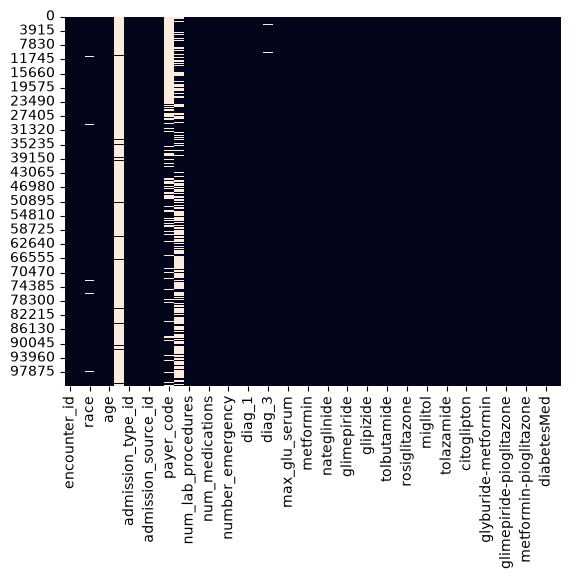

In [7]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing[missing > 0]

# Placeholder text that is really "missing"
for col in ["gender", "race", "max_glu_serum", "A1Cresult"]:
    print(df[col].value_counts(dropna=False), "\n")

sns.heatmap(df.isnull(), cbar=False)

<Axes: xlabel='readmitted', ylabel='count'>

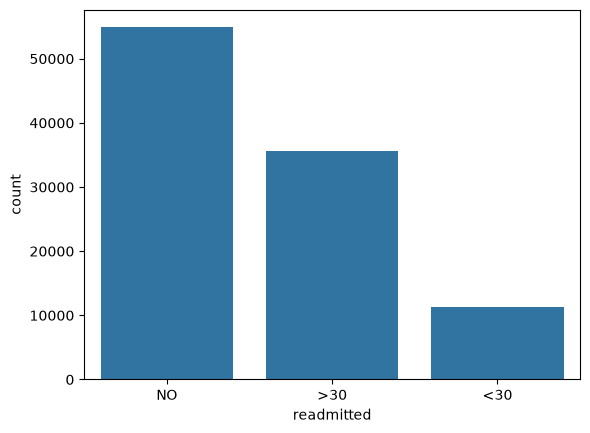

In [8]:
df["readmitted"].value_counts(normalize=True)
df["target"] = (df["readmitted"] == "<30").astype(int)
df["target"].value_counts(normalize=True)
sns.countplot(x="readmitted", data=df)

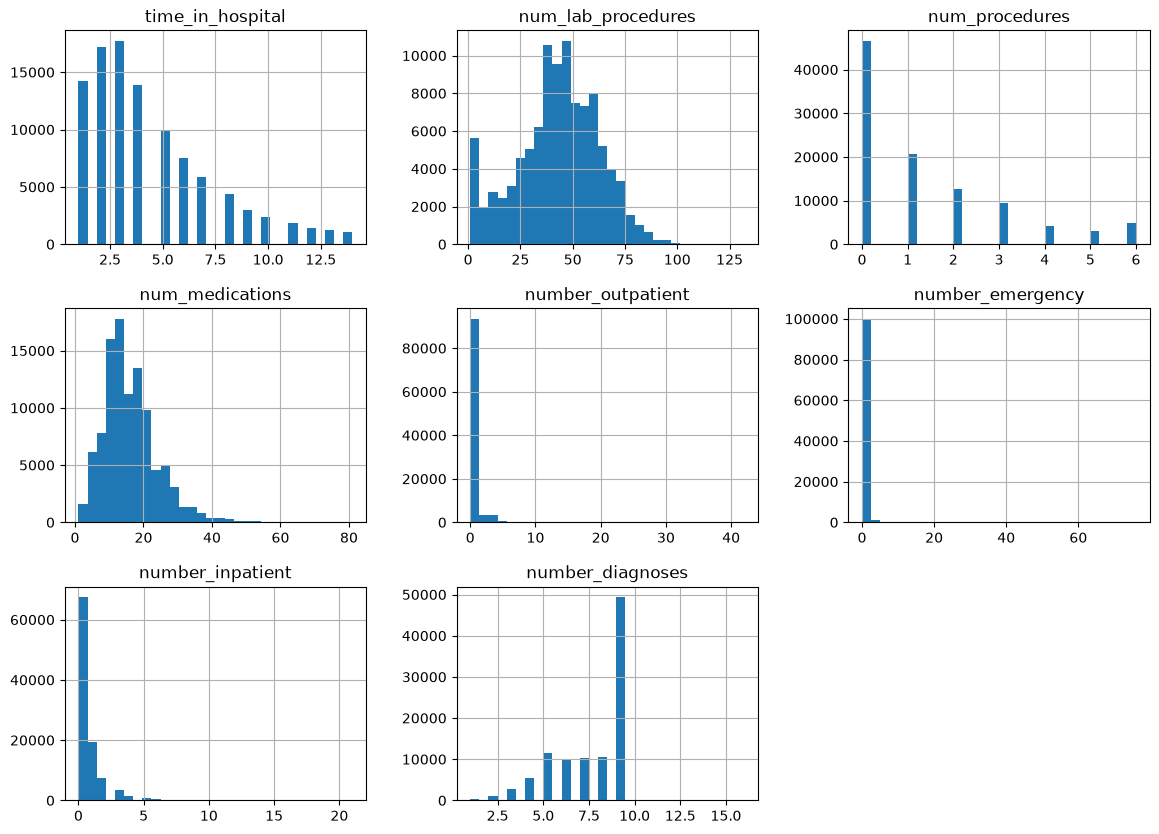

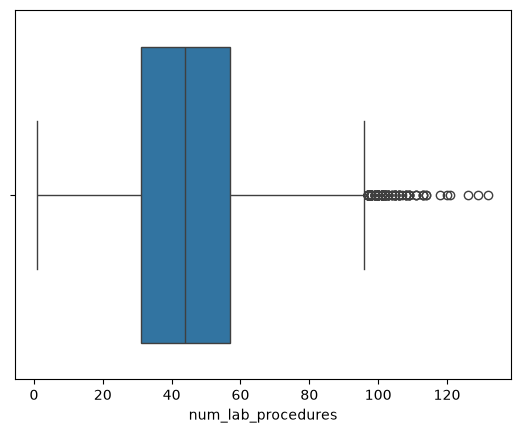

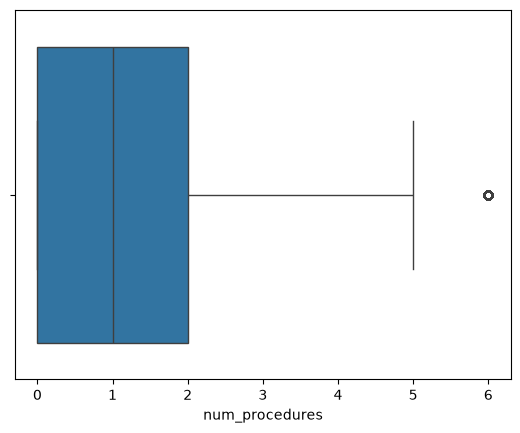

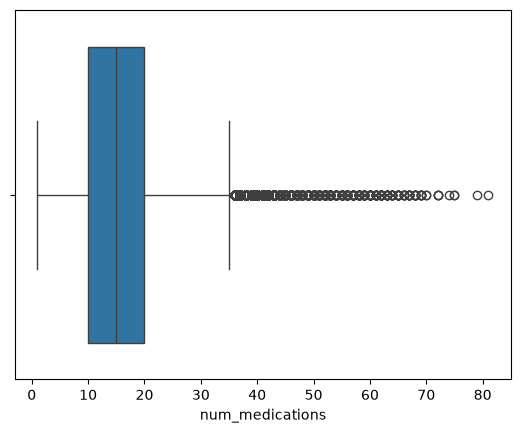

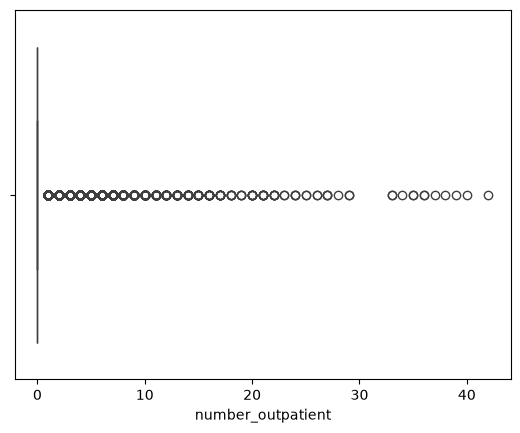

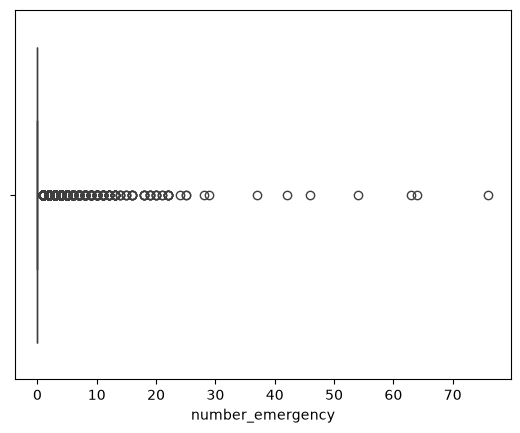

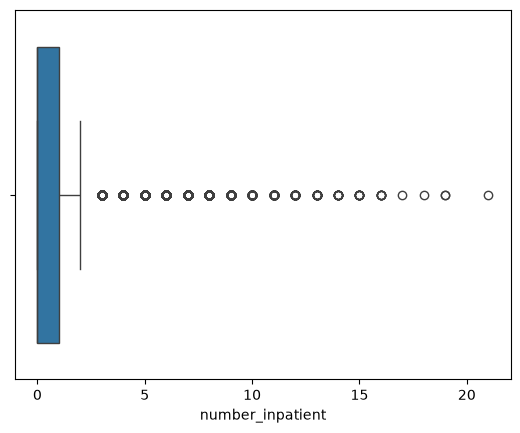

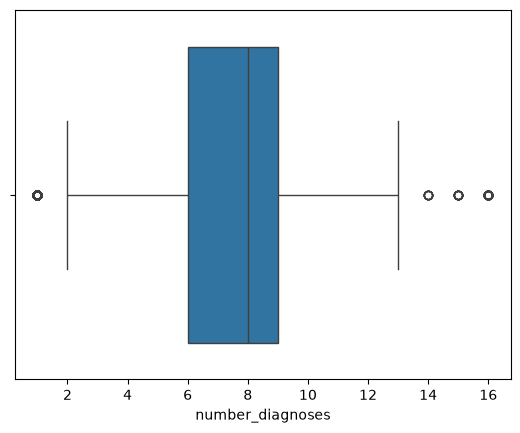

In [9]:
num_cols = ["time_in_hospital","num_lab_procedures","num_procedures",
            "num_medications","number_outpatient","number_emergency",
            "number_inpatient","number_diagnoses"]

df[num_cols].hist(bins=30, figsize=(14,10))
df[num_cols].skew()
for c in num_cols:
    sns.boxplot(x=df[c]); plt.show()

In [10]:
cat_cols = df.select_dtypes("object").columns
for c in cat_cols:
    print(c, df[c].nunique())
    print(df[c].value_counts(normalize=True).head(8), "\n")

/var/folders/v5/n1wx9t6s58j529b2h56vssc80000gn/T/ipykernel_90155/1860609739.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes("object").columns


race 5
race
Caucasian          0.764868
AfricanAmerican    0.193079
Hispanic           0.020474
Other              0.015137
Asian              0.006443
Name: proportion, dtype: float64 

gender 3
gender
Female             0.537586
Male               0.462384
Unknown/Invalid    0.000029
Name: proportion, dtype: float64 

age 10
age
[70-80)     0.256156
[60-70)     0.220928
[50-60)     0.169565
[80-90)     0.168986
[40-50)     0.095169
[30-40)     0.037095
[90-100)    0.027445
[20-30)     0.016282
Name: proportion, dtype: float64 

weight 9
weight
[75-100)     0.417892
[50-75)      0.280576
[100-125)    0.195496
[125-150)    0.045355
[25-50)      0.030341
[0-25)       0.015014
[150-175)    0.010948
[175-200)    0.003441
Name: proportion, dtype: float64 

payer_code 17
payer_code
MC    0.527378
HM    0.102000
SP    0.081401
BC    0.075679
MD    0.057422
CP    0.041180
UN    0.039798
CM    0.031491
Name: proportion, dtype: float64 

medical_specialty 72
medical_specialty
InternalMedicine  

In [11]:
drug_cols = df.columns[df.columns.get_loc("metformin"):df.columns.get_loc("metformin-pioglitazone")+1]
for c in drug_cols:
    print(c, df[c].value_counts(normalize=True).round(3).to_dict())

metformin {'No': 0.804, 'Steady': 0.18, 'Up': 0.01, 'Down': 0.006}
repaglinide {'No': 0.985, 'Steady': 0.014, 'Up': 0.001, 'Down': 0.0}
nateglinide {'No': 0.993, 'Steady': 0.007, 'Up': 0.0, 'Down': 0.0}
chlorpropamide {'No': 0.999, 'Steady': 0.001, 'Up': 0.0, 'Down': 0.0}
glimepiride {'No': 0.949, 'Steady': 0.046, 'Up': 0.003, 'Down': 0.002}
acetohexamide {'No': 1.0, 'Steady': 0.0}
glipizide {'No': 0.875, 'Steady': 0.112, 'Up': 0.008, 'Down': 0.006}
glyburide {'No': 0.895, 'Steady': 0.091, 'Up': 0.008, 'Down': 0.006}
tolbutamide {'No': 1.0, 'Steady': 0.0}
pioglitazone {'No': 0.928, 'Steady': 0.069, 'Up': 0.002, 'Down': 0.001}
rosiglitazone {'No': 0.937, 'Steady': 0.06, 'Up': 0.002, 'Down': 0.001}
acarbose {'No': 0.997, 'Steady': 0.003, 'Up': 0.0, 'Down': 0.0}
miglitol {'No': 1.0, 'Steady': 0.0, 'Down': 0.0, 'Up': 0.0}
troglitazone {'No': 1.0, 'Steady': 0.0}
tolazamide {'No': 1.0, 'Steady': 0.0, 'Up': 0.0}
examide {'No': 1.0}
citoglipton {'No': 1.0}
insulin {'No': 0.466, 'Steady': 0.303

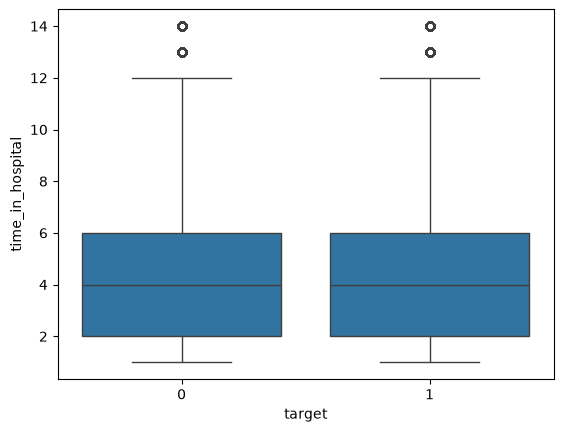

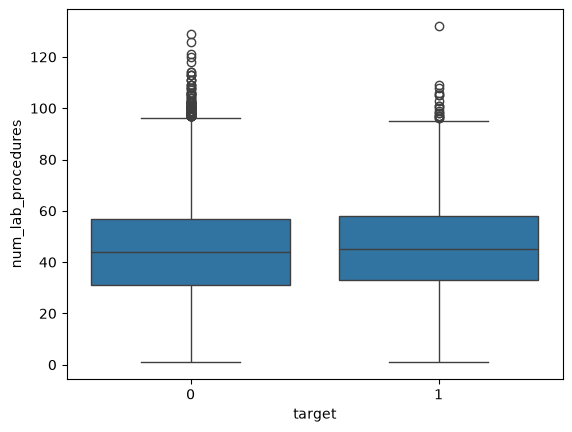

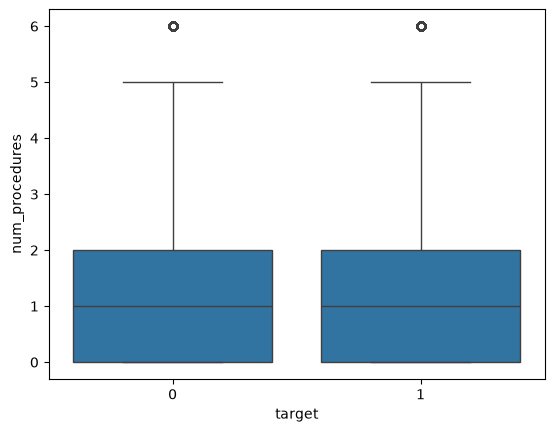

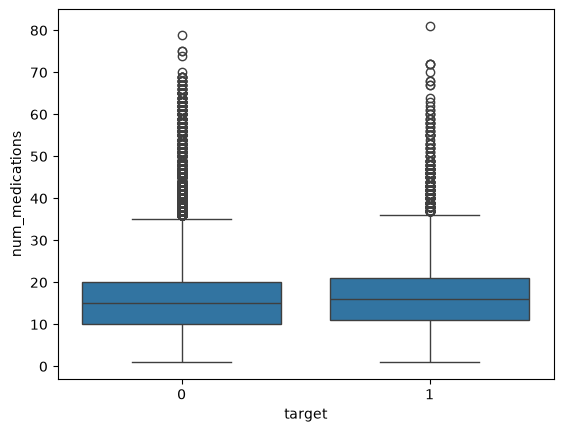

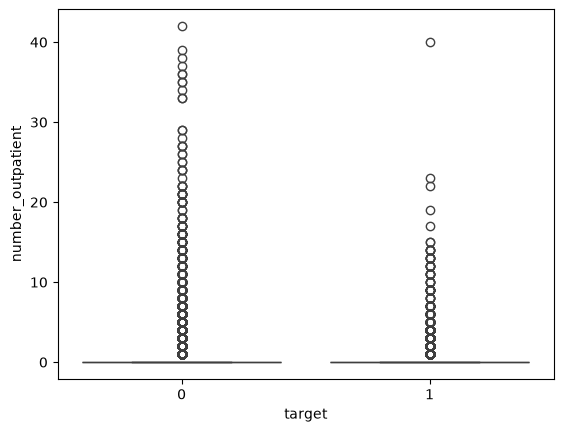

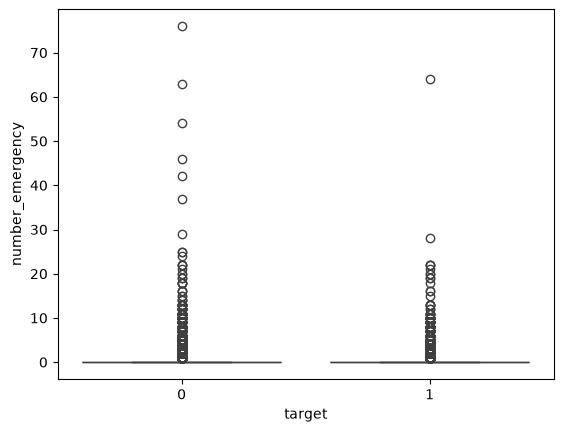

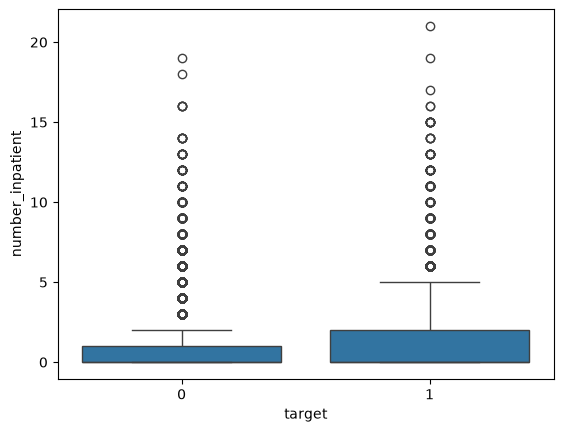

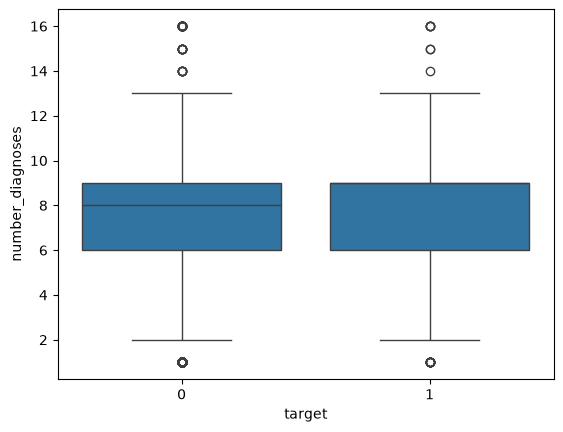

In [12]:
df.groupby("target")[num_cols].mean()
for c in num_cols:
    sns.boxplot(x="target", y=c, data=df); plt.show()

In [13]:
def rate_table(col):
    t = df.groupby(col)["target"].agg(["mean","count"]).sort_values("mean", ascending=False)
    t.columns = ["readmit_rate","n"]
    return t

for c in ["age","gender","race","admission_type_id","discharge_disposition_id",
          "admission_source_id","A1Cresult","change","diabetesMed"]:
    display(rate_table(c))

,readmit_rate,n
age,,
[20-30),0.142426,1657
[80-90),0.120835,17197
[70-80),0.117731,26068
[30-40),0.112318,3775
[60-70),0.111284,22483
[90-100),0.110992,2793
[40-50),0.106040,9685
[50-60),0.096662,17256
[10-20),0.057887,691


,readmit_rate,n
gender,,
Female,0.112452,54708
Male,0.110615,47055
Unknown/Invalid,0.000000,3


,readmit_rate,n
race,,
Caucasian,0.112906,76099
AfricanAmerican,0.112181,19210
Hispanic,0.104075,2037
Asian,0.101404,641
Other,0.096282,1506


,readmit_rate,n
admission_type_id,,
1,0.115225,53990
2,0.111797,18480
6,0.110754,5291
3,0.103927,18869
5,0.103448,4785
4,0.100000,10
8,0.084375,320
7,0.000000,21


,readmit_rate,n
discharge_disposition_id,,
12,0.666667,3
15,0.444444,63
9,0.428571,21
28,0.366906,139
22,0.276969,1993
5,0.208615,1184
2,0.160714,2128
3,0.146625,13954
24,0.145833,48


,readmit_rate,n
admission_source_id,,
22,0.166667,12
3,0.155080,187
20,0.136646,161
8,0.125000,16
5,0.118129,855
7,0.116882,57494
1,0.105868,29565
17,0.104114,6781
9,0.104000,125


,readmit_rate,n
A1Cresult,,
None,0.114233,84748
>7,0.100472,3812
>8,0.098710,8216
Norm,0.096593,4990


,readmit_rate,n
change,,
Ch,0.118228,47011
No,0.105908,54755


,readmit_rate,n
diabetesMed,,
Yes,0.116267,78363
No,0.095971,23403


<Axes: >

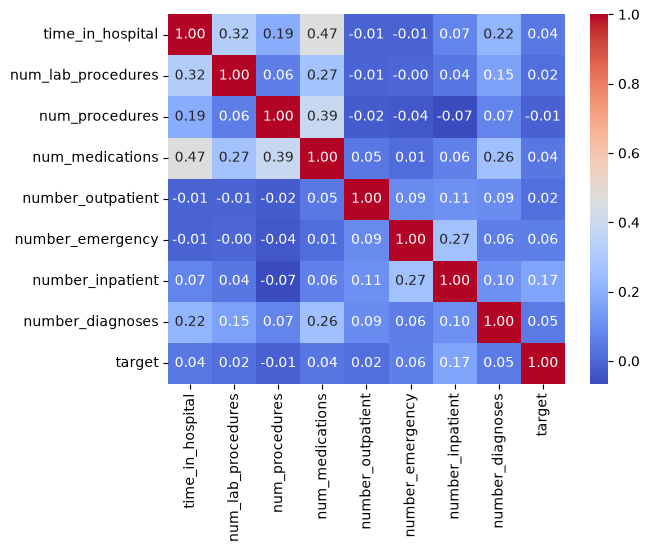

In [14]:
sns.heatmap(df[num_cols + ["target"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")

In [15]:
# 1. Same patient appearing multiple times
df["patient_nbr"].value_counts().describe()

# 2. Patients who died or went to hospice can't be readmitted
df["discharge_disposition_id"].isin([11,13,14,19,20,21]).sum()
rate_table("discharge_disposition_id")      # check these have ~0% readmission

# 3. Impossible or odd values
(df["time_in_hospital"] < 1).sum()
df[["num_medications","num_lab_procedures"]].max()

num_medications        81
num_lab_procedures    132
dtype: int64

In [16]:
for c in ["race","gender","age"]:
    display(rate_table(c))
    print(df[c].value_counts(normalize=True), "\n")

,readmit_rate,n
race,,
Caucasian,0.112906,76099
AfricanAmerican,0.112181,19210
Hispanic,0.104075,2037
Asian,0.101404,641
Other,0.096282,1506


race
Caucasian          0.764868
AfricanAmerican    0.193079
Hispanic           0.020474
Other              0.015137
Asian              0.006443
Name: proportion, dtype: float64 



,readmit_rate,n
gender,,
Female,0.112452,54708
Male,0.110615,47055
Unknown/Invalid,0.000000,3


gender
Female             0.537586
Male               0.462384
Unknown/Invalid    0.000029
Name: proportion, dtype: float64 



,readmit_rate,n
age,,
[20-30),0.142426,1657
[80-90),0.120835,17197
[70-80),0.117731,26068
[30-40),0.112318,3775
[60-70),0.111284,22483
[90-100),0.110992,2793
[40-50),0.106040,9685
[50-60),0.096662,17256
[10-20),0.057887,691


age
[70-80)     0.256156
[60-70)     0.220928
[50-60)     0.169565
[80-90)     0.168986
[40-50)     0.095169
[30-40)     0.037095
[90-100)    0.027445
[20-30)     0.016282
[10-20)     0.006790
[0-10)      0.001582
Name: proportion, dtype: float64 

